In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("usgs/earthquake-database")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 590k/590k [00:01<00:00, 484kB/s]

Extracting files...
Path to dataset files: C:\Users\Anshika\.cache\kagglehub\datasets\usgs\earthquake-database\versions\1


Dataset Shape: (23412, 21)
         Date      Time  Latitude  Longitude        Type  Depth  Depth Error  \
0  01/02/1965  13:44:18    19.246    145.616  Earthquake  131.6          NaN   
1  01/04/1965  11:29:49     1.863    127.352  Earthquake   80.0          NaN   
2  01/05/1965  18:05:58   -20.579   -173.972  Earthquake   20.0          NaN   
3  01/08/1965  18:49:43   -59.076    -23.557  Earthquake   15.0          NaN   
4  01/09/1965  13:32:50    11.938    126.427  Earthquake   15.0          NaN   

   Depth Seismic Stations  Magnitude Magnitude Type  ...  \
0                     NaN        6.0             MW  ...   
1                     NaN        5.8             MW  ...   
2                     NaN        6.2             MW  ...   
3                     NaN        5.8             MW  ...   
4                     NaN        5.8             MW  ...   

   Magnitude Seismic Stations  Azimuthal Gap  Horizontal Distance  \
0                         NaN            NaN                  

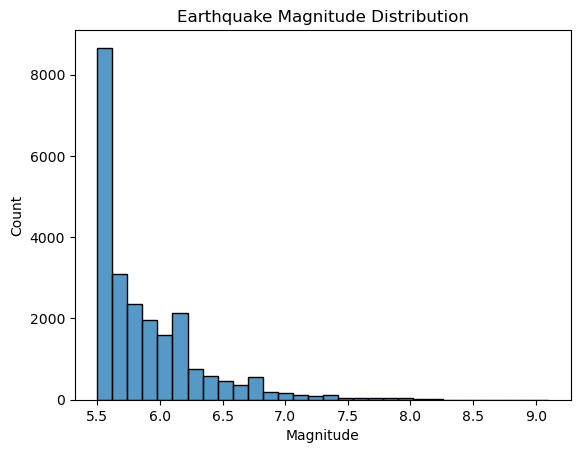

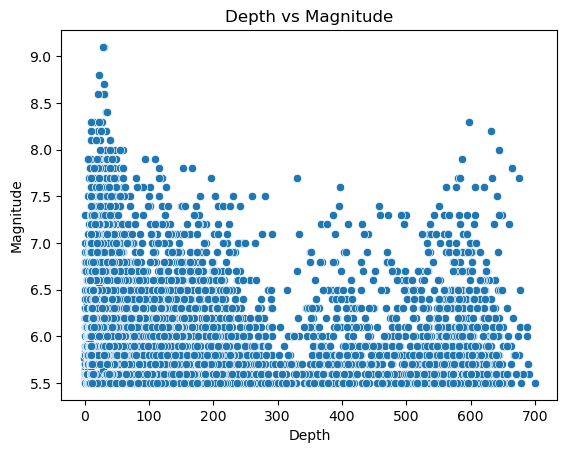

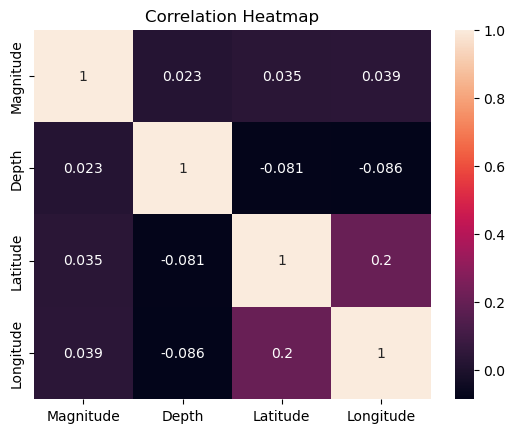

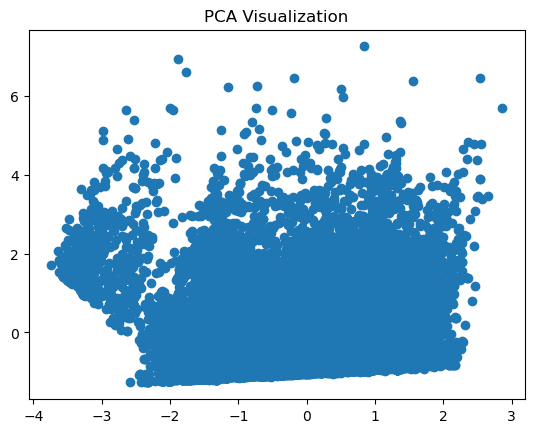

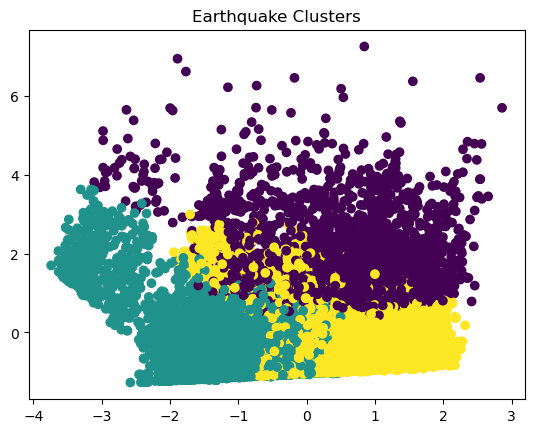

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      4683

    accuracy                           1.00      4683
   macro avg       1.00      1.00      1.00      4683
weighted avg       1.00      1.00      1.00      4683



C:\Users\Anshika\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


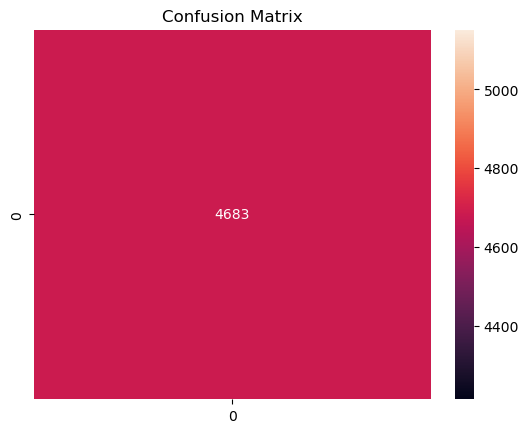

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1 Load Dataset
# -----------------------------

path = r"C:\Users\Anshika\.cache\kagglehub\datasets\usgs\earthquake-database\versions\1\database.csv"

df = pd.read_csv(path)

print("Dataset Shape:", df.shape)
print(df.head())

# -----------------------------
# 2 Select Important Features
# -----------------------------

df = df[['Magnitude','Depth','Latitude','Longitude']]

# Remove missing values
df.dropna(inplace=True)

# -----------------------------
# 3 Visualization
# -----------------------------

plt.figure()
sns.histplot(df['Magnitude'], bins=30)
plt.title("Earthquake Magnitude Distribution")
plt.show()

plt.figure()
sns.scatterplot(x='Depth', y='Magnitude', data=df)
plt.title("Depth vs Magnitude")
plt.show()

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 4 Feature Scaling
# -----------------------------

scaler = StandardScaler()

X = scaler.fit_transform(df)

# -----------------------------
# 5 PCA (Dimensionality Reduction)
# -----------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.show()

# -----------------------------
# 6 Clustering (K-Means)
# -----------------------------

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Earthquake Clusters")
plt.show()

# -----------------------------
# 7 Classification Target
# -----------------------------

df['Risk'] = (df['Magnitude'] > 5).astype(int)

X = df[['Depth','Latitude','Longitude']]
y = df['Risk']

# -----------------------------
# 8 Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 9 Train Model
# -----------------------------

model = RandomForestClassifier()

model.fit(X_train, y_train)

# -----------------------------
# 10 Prediction
# -----------------------------

pred = model.predict(X_test)

print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()